# Layerwise Probe Results

A minimal notebook for loading `results_rebuttal/layerwise_probe` JSON files and plotting accuracy versus probe layer fraction.

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections.abc import Sequence
from sklearn.metrics import balanced_accuracy_score

sns.set(style='whitegrid')

In [2]:
results_dir = 'results_rebuttal/layerwise_probe'
files = glob.glob(os.path.join(results_dir, '**', '*.json'), recursive=True)
rows = []


def _flatten_label_structure(values):
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def _compute_balanced_accuracy(y_true, y_pred):
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return np.nan

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    try:
        return balanced_accuracy_score(y_true_arr, y_pred_arr)
    except Exception:
        return np.nan


for f in files:
    try:
        with open(f, 'r') as fh:
            data = json.load(fh)
    except Exception:
        continue

    if not isinstance(data, dict):
        continue

    task = data.get('task_name') or data.get('task') or data.get('name') or data.get('eval_task')
    seed = data.get('seed') or data.get('random_seed')
    fraction = data.get('probe_layer') or data.get('probe_layer_fraction') or data.get('fraction') or data.get('layer_fraction')
    linear_probe = data.get('linear_probe')

    # Support different ways results record model names and per-model outputs
    model_names = data.get('models_names') or data.get('model_names') or data.get('model') or ['unknown']
    if isinstance(model_names, str):
        model_names = [model_names]

    result_prefix = (data.get('result_prefix') or '').replace('lejepa', '')

    # Try to infer fraction from filename if missing
    if fraction is None:
        basename = os.path.basename(f)
        tokens = basename.replace('.json', '').split('_')
        for tok in tokens:
            if tok.startswith('Lf') and tok[2:].isdigit():
                fraction = int(tok[2:]) / 100.0
                break

    results_all = data.get('results', [])
    y_tests = data.get('y_test', [])

    # If results are a single flat list (not per-model), keep as-is for each model
    for i, model_name in enumerate(model_names):
        try:
            if isinstance(results_all, list) and len(results_all) > i and any(isinstance(x, (list, np.ndarray)) for x in results_all):
                y_pred = results_all[i]
            else:
                y_pred = results_all

            if isinstance(y_tests, list) and len(y_tests) > i and any(isinstance(x, (list, np.ndarray)) for x in y_tests):
                y_true = y_tests[i]
            else:
                y_true = y_tests

            balanced_accuracy = _compute_balanced_accuracy(y_true, y_pred)

            if (balanced_accuracy is None or np.isnan(balanced_accuracy)):
                metrics = data.get('metrics') or {}
                balanced_accuracy = (
                    data.get('balanced_accuracy')
                    or data.get('bacc')
                    or data.get('bal_acc')
                    or metrics.get('balanced_accuracy')
                    or metrics.get('bacc')
                    or metrics.get('bal_acc')
                )

            if balanced_accuracy is not None and not np.isnan(balanced_accuracy) and fraction is not None:
                rows.append({
                    'file': f,
                    'task': task,
                    'seed': seed,
                    'fraction': float(fraction),
                    'balanced_accuracy': float(balanced_accuracy),
                    'linear_probe': linear_probe,
                    'model_name': model_name,
                    'model_display': str(result_prefix),
                })

        except Exception:
            # skip this model entry if parsing failed
            continue

columns = ['file', 'task', 'seed', 'fraction', 'balanced_accuracy', 'linear_probe', 'model_name', 'model_display']
df = pd.DataFrame(rows, columns=columns)
df = df.dropna(subset=['fraction', 'balanced_accuracy']).reset_index(drop=True)
df = df[df['linear_probe'].fillna(True)]

print(df.head())
print(sorted(df['task'].dropna().unique().tolist())) if not df.empty else print('No matching results yet.')

                                                file  \
0  results_rebuttal/layerwise_probe/raw/laya-b-20...   
1  results_rebuttal/layerwise_probe/raw/laya-mae-...   
2  results_rebuttal/layerwise_probe/raw/laya-b-20...   
3  results_rebuttal/layerwise_probe/raw/laya-b-20...   
4  results_rebuttal/layerwise_probe/raw/laya-b-20...   

                         task  seed  fraction  balanced_accuracy  \
0  Left Hand vs Right Hand MI    42     0.333           0.506191   
1           epilepsy_clinical   123     0.500           0.676398   
2  Left Hand vs Right Hand MI   456     1.000           0.502040   
3           abnormal_clinical    42     0.250           0.778413   
4       Right Hand vs Feet MI    42     1.000           0.592037   

   linear_probe      model_name     model_display  
0          True       LeJEPABCI  laya-b-20k-02sig  
1          True  LeJEPAClinical      laya-mae-raw  
2          True       LeJEPABCI  laya-b-20k-02sig  
3          True  LeJEPAClinical  laya-b-20k-02

In [3]:
df['model_display'].unique()

array(['laya-b-20k-02sig', 'laya-mae-raw'], dtype=object)

In [4]:
if df.empty:
    agg_all = pd.DataFrame(columns=['fraction', 'mean', 'std', 'count'])
    agg_task = pd.DataFrame(columns=['task', 'fraction', 'mean', 'std', 'count'])
    print('No data to aggregate yet.')
else:
    agg_all = df.groupby(['fraction', 'model_display'])['balanced_accuracy'].agg(['mean', 'std', 'count']).reset_index().sort_values('fraction')
    agg_task = df.groupby(['model_display', 'task', 'fraction'])['balanced_accuracy'].agg(['mean', 'std', 'count']).reset_index().sort_values(['task', 'fraction'])
    print(agg_all)
    print(agg_task.head())

    fraction     model_display      mean       std  count
0      0.250  laya-b-20k-02sig  0.599969  0.177077     18
1      0.250      laya-mae-raw  0.607836  0.185782     18
2      0.333  laya-b-20k-02sig  0.597920  0.174277     18
3      0.333      laya-mae-raw  0.607836  0.185782     18
4      0.500  laya-b-20k-02sig  0.596064  0.174780     18
5      0.500      laya-mae-raw  0.605142  0.184973     18
6      0.667  laya-b-20k-02sig  0.584982  0.163299     18
7      0.667      laya-mae-raw  0.588837  0.180650     18
8      0.750  laya-b-20k-02sig  0.584523  0.166261     18
9      0.750      laya-mae-raw  0.588837  0.180650     18
10     1.000  laya-b-20k-02sig  0.581349  0.162555     18
11     1.000      laya-mae-raw  0.585150  0.177224     18
       model_display                        task  fraction      mean  \
0   laya-b-20k-02sig  Left Hand vs Right Hand MI     0.250  0.508261   
36      laya-mae-raw  Left Hand vs Right Hand MI     0.250  0.504912   
1   laya-b-20k-02sig  Left Han

/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packa

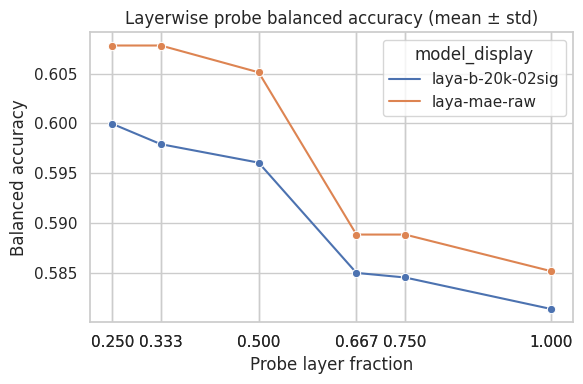

In [5]:
if agg_all.empty:
    print('No aggregated data to plot yet.')
else:
    plt.figure(figsize=(6, 4))
    sns.lineplot(data=agg_all, x='fraction', y='mean', hue='model_display', marker='o')
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy')
    plt.title('Layerwise probe balanced accuracy (mean ± std)')
    plt.xticks(agg_all['fraction'])
    plt.tight_layout()
    plt.show()

/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


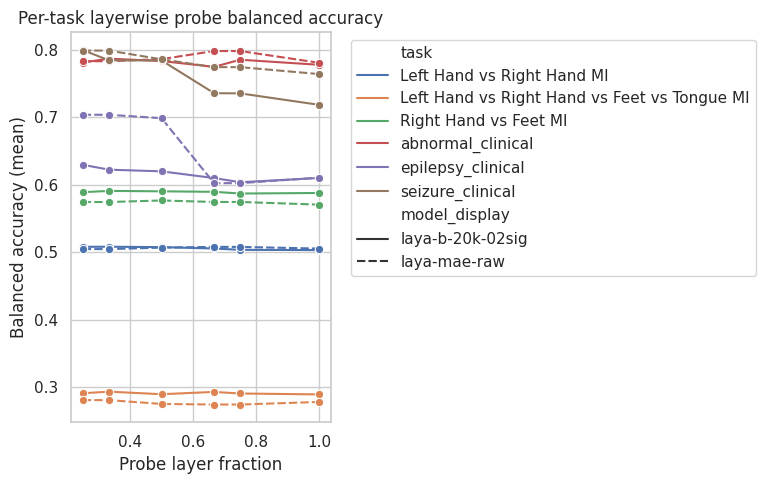

In [6]:
if agg_task.empty:
    print('No per-task data to plot yet.')
else:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=agg_task, x='fraction', y='mean', hue='task', style = 'model_display', marker='o')
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy (mean)')
    plt.title('Per-task layerwise probe balanced accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [7]:
out_dir = results_dir
os.makedirs(out_dir, exist_ok=True)

if agg_all.empty:
    print('No plots saved because no layerwise results were found yet.')
else:
    plt.figure(figsize=(6, 4))
    plt.errorbar(agg_all['fraction'], agg_all['mean'], yerr=agg_all['std'], fmt='-o', capsize=4)
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'layerwise_balanced_accuracy.png'), dpi=150)
    plt.close()

    agg_task.to_csv(os.path.join(out_dir, 'layerwise_per_task_balanced_accuracy.csv'), index=False)
    print('Saved plots and CSV to', out_dir)

Saved plots and CSV to results_rebuttal/layerwise_probe
